In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df=pd.read_csv("spotify_list.csv")

# Data Cleaning & Preprocessing

In [102]:
a=df.isnull().sum()
print(a)

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


From the dataset, it was observed that the "artists", "album_name", and "track_name" columns contain 1 missing value each.

Since the total number of missing values is very small, those rows were removed to maintain data quality.



In [103]:
df=df.dropna()

# ***All further analysis is performed on the cleaned dataset.***

# Data Overview

## Total number of songs in the dataset

In [104]:
r,c=df.shape
print("Total number of songs:",r)

Total number of songs: 113999


Answer: There are 113,999 songs in the Spotify dataset

## Total number of unique artists

In [105]:
a=df["artists"].nunique()
print(f"Number of unique artists: {a}")

Number of unique artists: 31437


Answer: There are 31,437 unique artists in the dataset.

## Number of unique genres

In [106]:
a=df["track_genre"].nunique()
print("Number of unique genres:",a)

Number of unique genres: 114


Answer: There are 114 unique genres in the dataset.

# Popularity Analysis

## Which song has the highest popularity?

In [107]:
a=df.loc[df["popularity"].idxmax()]
print(f"Song with highest popularity is:",a["track_name"])
print("Popularity:",a["popularity"])
print("Artists:",a["artists"])

Song with highest popularity is: Unholy (feat. Kim Petras)
Popularity: 100
Artists: Sam Smith;Kim Petras


Answer: "Unholy (feat. Kim Petras)" by Sam Smith & Kim Petras is the most popular song in the dataset, with a popularity score of 100.

## Top 10 most popular songs

In [108]:
df1=df.copy()
df1=df1.drop_duplicates(subset=["track_name","artists"])

top10_songs=df1.sort_values(by="popularity",ascending=False).head(10).reset_index(drop=True)
print(top10_songs[["track_name", "artists", "popularity"]])

                              track_name                     artists  \
0              Unholy (feat. Kim Petras)        Sam Smith;Kim Petras   
1  Quevedo: Bzrp Music Sessions, Vol. 52            Bizarrap;Quevedo   
2                             La Bachata               Manuel Turizo   
3                        I'm Good (Blue)     David Guetta;Bebe Rexha   
4                        Me Porto Bonito  Bad Bunny;Chencho Corleone   
5                       Tití Me Preguntó                   Bad Bunny   
6                                 Efecto                   Bad Bunny   
7                    Under The Influence                 Chris Brown   
8                        I Ain't Worried                 OneRepublic   
9                              As It Was                Harry Styles   

   popularity  
0         100  
1          99  
2          98  
3          98  
4          97  
5          97  
6          96  
7          96  
8          96  
9          95  


Asnwer: The table above shows the top 10 most popular songs along with their respective artists and popularity scores.

Duplicate entries based on track name and artist were removed to ensure that each song is considered only once in the analysis.

## Which artist has the highest average popularity?

In [109]:
df2=df.copy()
df2=df2.drop_duplicates(subset=["track_name","artists"])

df2["artists"]=df2["artists"].str.split(";")
df2=df2.explode("artists")
df2=df2.dropna(subset=["artists"])
df2["artists"]=df2["artists"].astype(str).str.strip()

avg_popularity=df2.groupby("artists")["popularity"].mean()
artist=avg_popularity.idxmax()
number_of_songs=df2["artists"].value_counts()[artist]

print("Artist with highest mean popularity:",artist)
print("Highest mean popularity:",avg_popularity.max())
print(f"Number of songs by {artist} is: {number_of_songs}")

Artist with highest mean popularity: Bizarrap
Highest mean popularity: 99.0
Number of songs by Bizarrap is: 1


Answer: A copy of the original dataframe was created to avoid modifying the original data.


The "artists" column had more than one artists for multiple songs, so it was first split and the expanded using explode() function to analyze the popularity of each artists individually.

Bizarrap has the highest average popularity score of 99. However, this is based on only 1 song, which may lead to a biased result.

## Top 5 genres based on total popularity

In [110]:
top5=df.groupby("track_genre")["popularity"].sum().sort_values(ascending=False).head(5)
print(top5)

track_genre
pop-film    59283
k-pop       56896
chill       53651
sad         52379
grunge      49594
Name: popularity, dtype: int64


Answer: The top 5 genres based on total popularity are:

1. "**pop-film**" -    59,283
2. "**k-pop**" -       56,896
3. "**chill**" -       53,651
4. "**sad**" -         52,379
5. "**grunge**" -      49,594

# Audio Feature Analysis

## Average energy, danceability, and valence across top 10 genres (visualized using a heatmap)

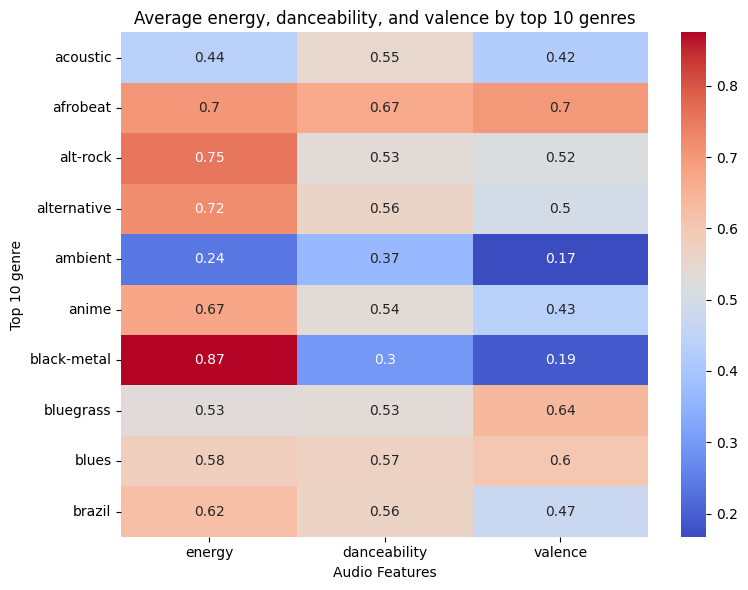

In [111]:
top10_genre=df["track_genre"].value_counts().head(10).index #find the top 10 genre
top10_filtered=df.loc[(df["track_genre"].isin(top10_genre))] #select the rows with that top 10 genre
a=top10_filtered.groupby("track_genre")[["energy","danceability","valence"]].mean() #calculate average values per genre

plt.figure(figsize=(8,6))
sns.heatmap(a,annot=True,cmap="coolwarm")
plt.title("Average energy, danceability, and valence by top 10 genres")
plt.xlabel("Audio Features")
plt.ylabel("Top 10 genre")
plt.tight_layout()

Answer: The heatmap above shows the average energy, danceability, and valence for the top 10 genres. It helps compare the musical characteristics of different genres.

## Relationship between: energy vs popularity (scatter plot)

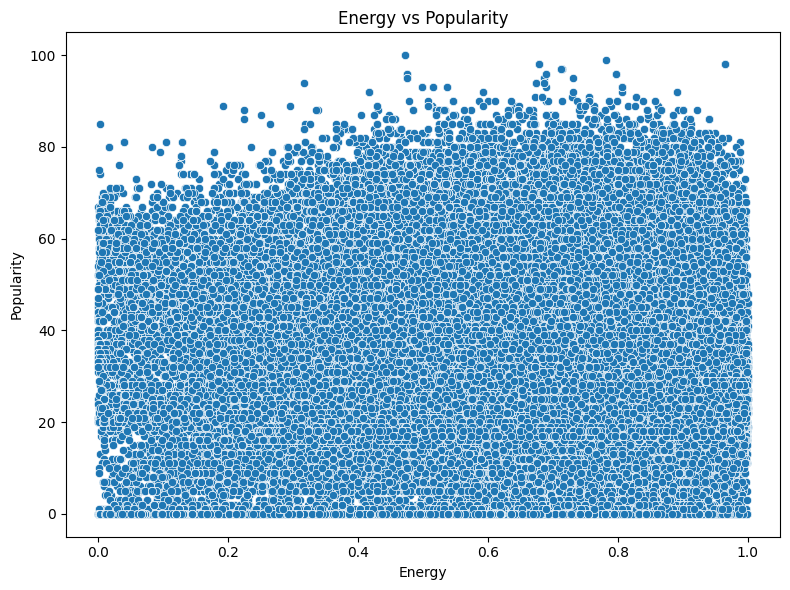

In [112]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="energy",y="popularity",data=df)
plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.tight_layout()

Answer:
From the scatter plot, the data points are widely dispersed, indicating a weak or negligible relationship between energy and popularity.

This suggests that a song’s energy level does not significantly influence its popularity.

## Which songs have: High energy (>0.8) & Low popularity (<30)

In [113]:
a=df.loc[(df["energy"]>0.8) & (df["popularity"]<30)].reset_index(drop=True)
print(a[["track_name", "artists", "energy", "popularity"]])

                                           track_name              artists  \
0                                             Hold On          KT Tunstall   
1                                       Sleep All Day           Jason Mraz   
2                                      No Stopping Us           Jason Mraz   
3                                       Too Much Food           Jason Mraz   
4                                 On Love, in Sadness           Jason Mraz   
...                                               ...                  ...   
18509               Para Reiki: Gotas de Agua, Pt. 17        Reiki Armonía   
18510  Hermosa Daydream (Música Tranquila y Pacífica)         Flor de Loto   
18511                               You Are My Vision      Rend Collective   
18512                                    Incontenible        Planetshakers   
18513     Concentración: Sonidos de la Lluvia, Pt. 01  Fondo de la lectura   

       energy  popularity  
0       0.937           0  
1      

The table above lists songs that have high energy (> 0.8) but low popularity (< 30)

# Recommendation System

Recommend similar songs based on a given song (Same genre,Closest energy + popularity)

In [114]:
df3=df.copy()
df3=df3.drop_duplicates(subset=["track_name","artists"])

# Example input song (can be changed)
song_name = "Shape of You"
if song_name in df3["track_name"].values:

  genre=df3.loc[df3["track_name"]==song_name,"track_genre"].values[0]
  filtered = df3.loc[df3["track_genre"] == genre]
  filtered=filtered.copy()

  e=df3.loc[(df3["track_name"]==song_name),"energy"].values[0]
  p=df3.loc[(df3["track_name"]==song_name),"popularity"].values[0]

  filtered["diff_energy"]=abs(filtered["energy"]-e)
  filtered["diff_popularity"]=abs(filtered["popularity"]-p)

  filtered["score"]=filtered["diff_energy"]+filtered["diff_popularity"]

  filtered=filtered.loc[filtered["track_name"]!=song_name]
  recommendations=filtered.sort_values(by="score").head(5)

  print(recommendations[["track_name","artists","energy","popularity","track_genre"]].reset_index(drop=True))
else:
  print("Song not found")

                               track_name                             artists  \
0                                  august                        Taylor Swift   
1  Peaches (feat. Daniel Caesar & Giveon)  Justin Bieber;Daniel Caesar;Giveon   
2                            In The Stars                        Benson Boone   
3                                 happier                      Olivia Rodrigo   
4                                Infinity                        Jaymes Young   

   energy  popularity track_genre  
0   0.623          86         pop  
1   0.696          86         pop  
2   0.540          86         pop  
3   0.443          86         pop  
4   0.673          85         pop  


The system recommends songs that are most similar to the selected song based on energy and popularity.

For the input song "Shape of You", the model calculates the ***difference in energy and popularity with all other songs***, combines them into a similarity score, and returns the top 5 closest songs.

These recommended songs have similar musical characteristics to the input song.

Note: For demonstration purposes, a fixed input value is used instead of user input. The input can be modified in the code to test different scenarios

## Mood-Based Recommendation System
Create categories:
1. 😌 Chill → low energy, high acousticness
2. 🔥 Energetic → high energy
3. 🎉 Party → high danceability + valence

In [115]:
df4=df.copy()
df4 = df4.drop_duplicates(subset=["track_name", "artists"])

mood="Party"

if mood=="Chill":
  a=df4.loc[(df4["energy"]<0.3) & (df4["acousticness"]>0.5)]
  recommendations=a.sort_values(by="popularity",ascending=False).head(10).reset_index(drop=True)
  print(recommendations[["track_name","artists","popularity","energy","acousticness"]])

elif mood=="Energetic":
  b=df4.loc[df4["energy"]>0.7]
  recommendations=b.sort_values(by="popularity",ascending=False).head(10).reset_index(drop=True)
  print(recommendations[["track_name","artists","popularity","energy"]])

elif mood=="Party":
  c=df4.loc[(df4["danceability"]>0.7) & (df4["valence"]>0.6)]
  recommendations=c.sort_values(by="popularity",ascending=False).head(10).reset_index(drop=True)
  print(recommendations[["track_name","artists","popularity","danceability","valence"]])

else:
  print("Invalid Mood")

                                          track_name  \
0                                         La Bachata   
1                                    I Ain't Worried   
2                                            CUFF IT   
3                                  Super Freaky Girl   
4            Left and Right (Feat. Jung Kook of BTS)   
5                      Calm Down (with Selena Gomez)   
6  Vegas (From the Original Motion Picture Soundt...   
7                                            Ferrari   
8                                     BILLIE EILISH.   
9                                    About Damn Time   

                      artists  popularity  danceability  valence  
0               Manuel Turizo          98         0.835    0.850  
1                 OneRepublic          96         0.704    0.825  
2                     Beyoncé          93         0.780    0.642  
3                 Nicki Minaj          92         0.950    0.912  
4  Charlie Puth;Jung Kook;BTS          92       

Answer:
Songs are recommended based on different moods by applying filters on audio features such as energy, acousticness, danceability, and valence.

Duplicate entries were removed to ensure that only unique songs are recommended. Based on the selected mood, songs satisfying the defined conditions are filtered and then sorted by popularity to display the top 10 most relevant tracks.

Note: For demonstration purposes, a fixed input value is used instead of user input. The input can be modified in the code to test different scenarios

# Similarity Score Recommendation

In [116]:
df5=df.copy()
df5=df5.drop_duplicates(subset=["track_name","artists"])

song_name="Comedy"

if song_name in df5["track_name"].values:

  e=df5.loc[(df5["track_name"]==song_name),"energy"].values[0]
  p=df5.loc[(df5["track_name"]==song_name),"popularity"].values[0]
  d=df5.loc[(df5["track_name"]==song_name),"danceability"].values[0]

  df5["diff_energy"]=abs(df5["energy"]-e)
  df5["diff_popularity"]=abs(df5["popularity"]-p)
  df5["diff_danceability"]=abs(df5["danceability"]-d)

  df5["score"]=df5["diff_energy"]+df5["diff_popularity"]+df5["diff_danceability"]
  df5=df5.loc[(df5["track_name"]!=song_name)]
  recommendations=df5.sort_values(by="score").head(5).reset_index(drop=True)
  print(recommendations[["track_name","artists","energy","popularity","danceability","track_genre"]])

else:
  print("Song not found")

             track_name        artists  energy  popularity  danceability  \
0    People Are Strange      The Doors   0.467          73         0.699   
1              It's You        Sezairi   0.456          73         0.630   
2  You Know I'm No Good  Amy Winehouse   0.496          73         0.694   
3       Jhoom - R&B Mix      Ali Zafar   0.400          73         0.662   
4         like i need u          keshi   0.465          73         0.748   

         track_genre  
0         psych-rock  
1  singer-songwriter  
2            british  
3           pop-film  
4              chill  


Answer:
Songs are recommended by calculating a similarity score using multiple audio features such as energy, popularity, and danceability. The songs with the lowest scores are considered most similar to the input song and are returned as recommendations.

# Visualization

## Top genres by popularity (Top 10)

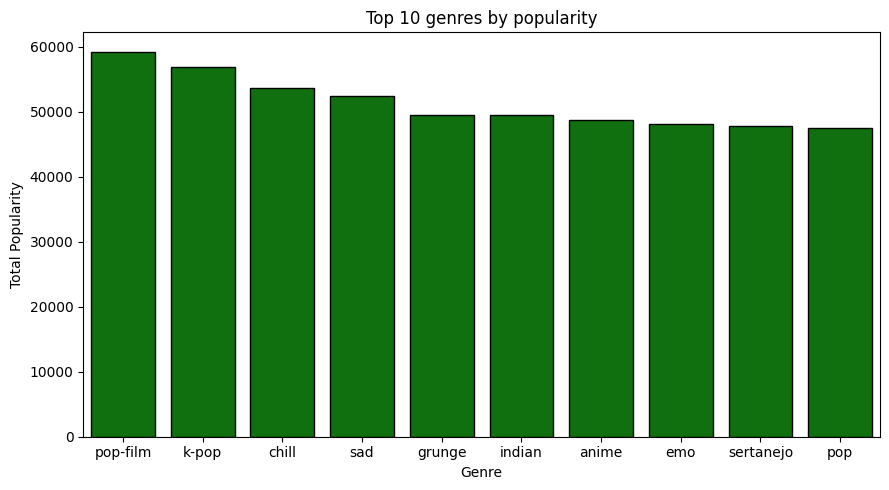

In [117]:
top_genre=df.groupby("track_genre")["popularity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(x=top_genre.index,y=top_genre.values,color="green",edgecolor="black")
plt.title("Top 10 genres by popularity")
plt.xlabel("Genre")
plt.ylabel("Total Popularity")
plt.tight_layout()


Answer:
The bar chart shows the top 10 genres based on total popularity. Genres like pop-film have the highest overall popularity, followed by k-pop and chill, indicating they are more widely listened to compared to others.

## Popularity distribution

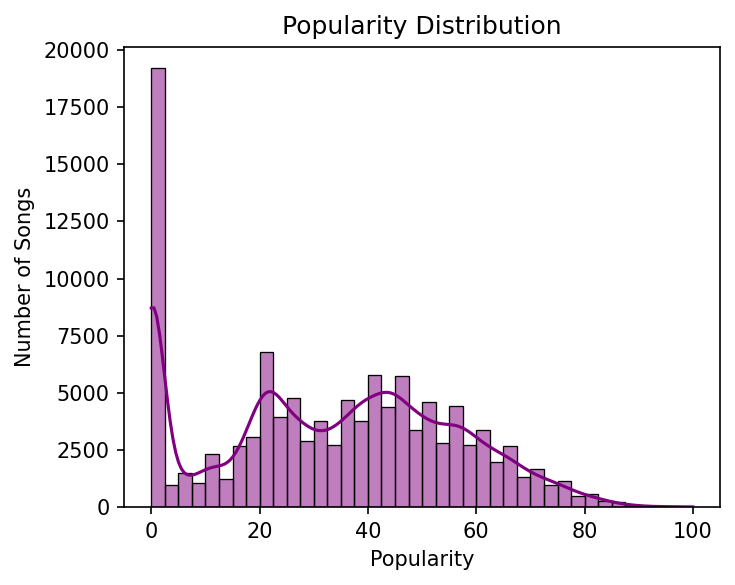

In [118]:
plt.figure(figsize=(5,4),dpi=150)
sns.histplot(x="popularity",bins=40,kde=True,data=df,color="purple")
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.tight_layout()

Answer:
From the histogram, it can be observed that a large number of songs have a popularity score of 0, indicating many tracks are not widely recognized. Additionally, most songs fall within the 20 to 60 popularity range, while very few songs achieve extremely high popularity

## Top 10 artists

In [ ]:
df6=df.copy()
df6=df6.drop_duplicates(subset=["track_name","artists"])

df6["artists"]=df6["artists"].str.split(";")
df6=df6.explode("artists")
df6=df6.dropna(subset=["artists"])
df6["artists"]=df6["artists"].astype(str).str.strip()

top=df6["artists"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top.values,y=top.index)
plt.tight_layout()
plt.title("Top 10 Artists")
plt.xlabel("Number of songs")
plt.ylabel("Artists")

Answer:
The bar chart shows the top 10 artists based on the number of songs in the dataset. These artists have contributed the highest number of tracks compared to other